🚀 [Step 3] LightGBM 유량/수압 개별 학습 시작...

📊 [유량(Flow) 모델 최종 성적표]
  - 결정계수 (R²): 0.3498
  - 평균 절대 오차 (MAE): 0.1155 (Scaled) ➡️ 22.28 (L/min)
  - 제곱근 평균 제곱 오차 (RMSE): 0.1525 (Scaled) ➡️ 29.42 (L/min)

📊 [수압(Pressure) 모델 최종 성적표]
  - 결정계수 (R²): 0.8055
  - 평균 절대 오차 (MAE): 0.0525 (Scaled) ➡️ 0.13 (kPa)
  - 제곱근 평균 제곱 오차 (RMSE): 0.0748 (Scaled) ➡️ 0.18 (kPa)

🛡️ [Step 5] 삼중 검증 엔진 가동 및 필터링 중...

✅ 모델 3종 저장 완료: ../models


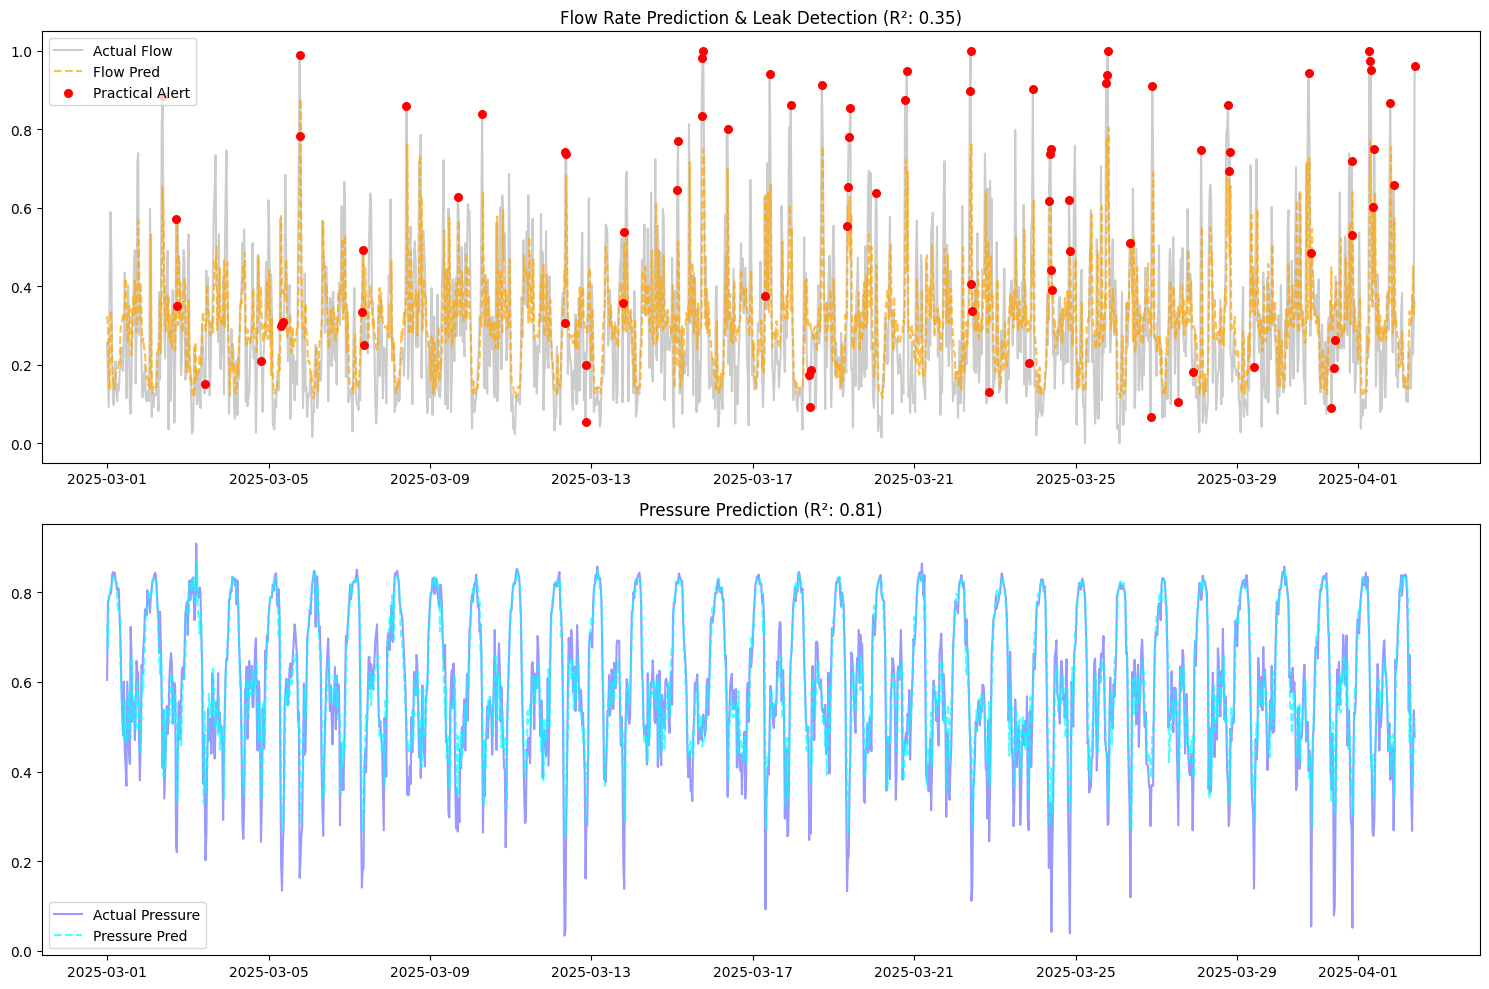

🚩 최종 누수 의심 알람 횟수: 85회


In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 경로 설정
input_path = '../data/processed/smart_meter_final.csv'
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# 시계열 인덱스로 로드
df = pd.read_csv(input_path, index_col='Timestamp', parse_dates=True)
scaler = joblib.load('../models/minmax_scaler.pkl')

# 2. 특성 공학 (30분 단위에 맞춘 Lag 변수 생성)
def create_features(df):
    df = df.copy()
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dayofweek'] = df.index.dayofweek
    # 30분 단위이므로 과거 1시간은 i=1, 2 (30분, 60분)
    for i in range(1, 3):
        df[f'flow_lag_{i}'] = df['Flow_Instant'].shift(i)
        df[f'press_lag_{i}'] = df['Pressure'].shift(i)
    return df.dropna()

df_feat = create_features(df)

# 데이터 분할 (3월 기준)
train_df = df_feat[df_feat.index < '2025-03-01']
test_df = df_feat[df_feat.index >= '2025-03-01'].copy()

features = ['hour_sin', 'hour_cos', 'dayofweek'] + \
           [f'flow_lag_{i}' for i in range(1, 3)] + \
           [f'press_lag_{i}' for i in range(1, 3)]

# 3. 모델 학습 (유량 & 수압 개별 예측)
print("🚀 [Step 3] LightGBM 유량/수압 개별 학습 시작...")
model_flow = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, verbosity=-1)
model_flow.fit(train_df[features], train_df['Flow_Instant'])

model_press = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, verbosity=-1)
model_press.fit(train_df[features], train_df['Pressure'])

# 4. 성능 평가 함수 (수학적 지표 + 실측 단위 환산)
def evaluate_performance(actual, pred, name, unit, scaler_idx):
    # (A) 스케일링 지표 (0~1)
    mae_s = mean_absolute_error(actual, pred)
    rmse_s = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    
    # (B) 실측 단위 환산 (Scaler 정보 활용)
    data_range = scaler.data_max_[scaler_idx] - scaler.data_min_[scaler_idx]
    mae_r = mae_s * data_range
    rmse_r = rmse_s * data_range
    
    print(f"\n📊 [{name} 모델 최종 성적표]")
    print(f"  - 결정계수 (R²): {r2:.4f}")
    print(f"  - 평균 절대 오차 (MAE): {mae_s:.4f} (Scaled) ➡️ {mae_r:.2f} ({unit})")
    print(f"  - 제곱근 평균 제곱 오차 (RMSE): {rmse_s:.4f} (Scaled) ➡️ {rmse_r:.2f} ({unit})")
    return r2

# 예측 수행 및 지표 산출
test_df['flow_pred'] = model_flow.predict(test_df[features])
test_df['press_pred'] = model_press.predict(test_df[features])

r2_f = evaluate_performance(test_df['Flow_Instant'], test_df['flow_pred'], "유량(Flow)", "L/min", 0)
r2_p = evaluate_performance(test_df['Pressure'], test_df['press_pred'], "수압(Pressure)", "kPa", 1)

# 5. 삼중 검증 로직 (Isolation Forest + Z-score + 지속성)
print("\n🛡️ [Step 5] 삼중 검증 엔진 가동 및 필터링 중...")
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(train_df[['Flow_Instant', 'Pressure']])
test_df['iso_anomaly'] = iso_forest.predict(test_df[['Flow_Instant', 'Pressure']])

# Z-score 필터 (유량 잔차 기반)
res_ewma = (test_df['Flow_Instant'] - test_df['flow_pred']).ewm(span=8).mean()
z_score = (res_ewma - res_ewma.mean()) / res_ewma.std()
test_df['z_flag'] = z_score.abs() > 3.0

# 최종 알람 (30분 단위이므로 즉각 판정 혹은 2회 연속(1시간) 설정 가능)
test_df['is_anomaly_instant'] = (test_df['z_flag'] == True) | (test_df['iso_anomaly'] == -1)
test_df['final_alert'] = test_df['is_anomaly_instant']

# 6. 모델 저장 (배포용 3종 세트)
joblib.dump(model_flow, f'{model_dir}/lgbm_leak_predictor.pkl')
joblib.dump(model_press, f'{model_dir}/pressure_predictor.pkl')
joblib.dump(iso_forest, f'{model_dir}/iso_forest_validator.pkl')
print(f"\n✅ 모델 3종 저장 완료: {model_dir}")

# 7. 시각화
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(test_df.index, test_df['Flow_Instant'], label='Actual Flow', alpha=0.4, color='gray')
plt.plot(test_df.index, test_df['flow_pred'], label='Flow Pred', alpha=0.7, color='orange', ls='--')
alerts = test_df[test_df['final_alert'] == True]
plt.scatter(alerts.index, alerts['Flow_Instant'], color='red', s=30, label='Practical Alert', zorder=5)
plt.title(f'Flow Rate Prediction & Leak Detection (R²: {r2_f:.2f})'); plt.legend()

plt.subplot(2, 1, 2)
plt.plot(test_df.index, test_df['Pressure'], label='Actual Pressure', color='blue', alpha=0.4)
plt.plot(test_df.index, test_df['press_pred'], label='Pressure Pred', color='cyan', alpha=0.7, ls='--')
plt.title(f'Pressure Prediction (R²: {r2_p:.2f})'); plt.legend()

plt.tight_layout(); plt.show()
print(f"🚩 최종 누수 의심 알람 횟수: {test_df['final_alert'].sum()}회")



🛡️ [실시간 누수 진단 실측 성능 평가]
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1473
     Anomaly       0.75      0.77      0.76        83

    accuracy                           0.97      1556
   macro avg       0.87      0.88      0.87      1556
weighted avg       0.97      0.97      0.97      1556

✅ 최종 진단 신뢰도 (F1-Score): 0.7619


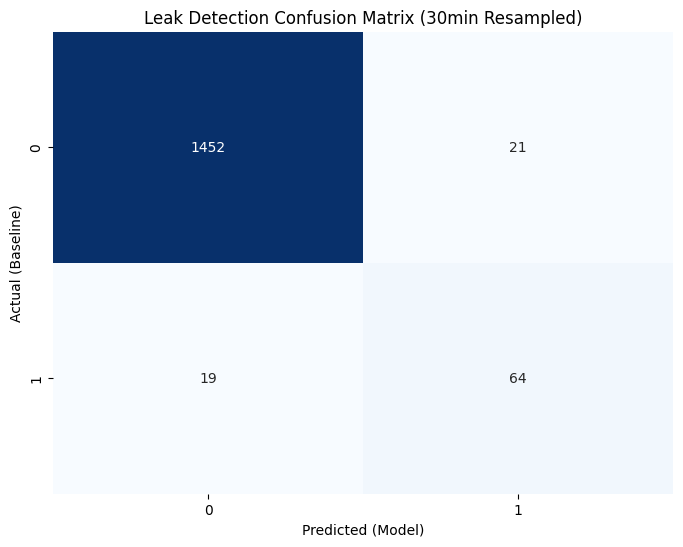

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

# 1. '가상 정답(Ground Truth)' 생성 
# 스케일링 된 데이터 기준: 유량이 상위권으로 튀거나, 수압이 하위권으로 급락한 지점
# (통계적 근거: 평균 + 2~3표준편차 수준을 이상 징후로 가이드)
flow_mean, flow_std = test_df['Flow_Instant'].mean(), test_df['Flow_Instant'].std()
press_mean, press_std = test_df['Pressure'].mean(), test_df['Pressure'].std()

test_df['actual_anomaly'] = (
    (test_df['Flow_Instant'] > flow_mean + 2.5 * flow_std) | 
    (test_df['Pressure'] < press_mean - 2.0 * press_std)
).astype(int)

# 2. 모델의 예측값 (final_alert)을 숫자로 변환
test_df['pred_anomaly'] = test_df['final_alert'].astype(int)

# 3. 분류 성능 지표 계산
print("\n🛡️ [실시간 누수 진단 실측 성능 평가]")
# 데이터에 이상치(Anomaly)가 적을 경우를 대비해 labels 지정
report = classification_report(
    test_df['actual_anomaly'], 
    test_df['pred_anomaly'], 
    target_names=['Normal', 'Anomaly'],
    zero_division=0
)
print(report)

# 4. F1-Score 추출
f1 = f1_score(test_df['actual_anomaly'], test_df['pred_anomaly'], zero_division=0)
print(f"✅ 최종 진단 신뢰도 (F1-Score): {f1:.4f}")

# 5. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_df['actual_anomaly'], test_df['pred_anomaly'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Leak Detection Confusion Matrix (30min Resampled)')
plt.xlabel('Predicted (Model)'); plt.ylabel('Actual (Baseline)')
plt.show()
